# Reproduce the paper exactly

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from run_experiment import ExperimentConfig, load_results, run_experiment, survivors_curve_from_escape_count
from src.utils.plotting import save_figure


## Define the relevant functions

In [19]:
def plot_survivor_curve(escape_count, n0, out_path, save_figure_flag = True):
    survivors = survivors_curve_from_escape_count(escape_count, n0)
    t = np.arange(survivors.shape[0])

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.semilogy(t, survivors)
    ax.set_xlabel('Revolutions')
    ax.set_ylabel('Survivors N(t)')
    ax.set_title('Survivor count vs time')
    ax.grid(True, which='both', alpha=0.3)

    if save_figure_flag:
        saved_path = save_figure(fig, out_path.stem, out_path.parent)
        plt.show()
        return saved_path
    else:
        plt.show()
        return None


def plot_survivor_scatter(points, title, out_path, fig_side = 15,  dot_size=1, save_figure_flag = True):
    fig, ax = plt.subplots(figsize=(fig_side, fig_side))
    ax.scatter(points[:, 0], points[:, 1], c='black', s=dot_size)
    ax.set_xlabel('z', fontsize = int(12*fig_side/12))
    ax.set_ylabel('v', fontsize = int(12*fig_side/12))
    ax.set_title(title, fontsize = int(14*fig_side/12))
    ax.tick_params(axis='both', which='major', labelsize=int(10*fig_side/12))
    ax.grid(True, alpha=0.2)
    ax.set_aspect('equal', adjustable='box')
    if save_figure_flag:
        saved_path = save_figure(fig, out_path.stem, out_path.parent)
        plt.show()
        return saved_path
    else:
        plt.show()
        return None


### Benchmark run

In [ ]:
config = ExperimentConfig(
    e=0.57,
    n0=10_000,
    z0=6.0,
    vmin=0.0,
    vmax=0.15,
    max_rev=160,
    escape_abs_z=10.0,
    rev_mid=9,
    rev_final=16,
    checkpoint_every_chunks=1,
    chunk_size=2_000,
    rtol=1e-7,
    atol=1e-10,
    solver_method='RK45',
    focal_interp='linear',
)

run_dir = run_experiment(
    config,
    run_label='benchmark_10k',
    resume=False,
    calibrate_chunk_size=False,
    parallel_workers=2,
)
run_dir

WindowsPath('C:/Users/Admin/Desktop/TFG/CelestialMechanics/sitnikov/experiments/chaotic_saddle_replicate/data/runs/benchmark_10k')

In [23]:
results = load_results(run_dir)
results['escape_count'], results['initial_points'].shape, results['intermediate_points'].shape, results['final_points'].shape

(array([   0,    0,    0,    0,    0, 2035, 1427, 1056,  726,  485,  415,
         436,  393,  356,  315,  298,  267,  226,  199,  159,  134,  114,
         102,   99,   72,   72,   59,   65,   54,   46,   37,   25,   42,
          30,   22,   15,   22,   16,   11,   17,   20,    8,    9,    8,
          12,    4,    8,    7,    3,    5,    7,    1,    7,    5,    4,
           3,    4,    4,    2,    0,    0,    4,    3,    0,    2,    2,
           2,    0,    1,    1,    0,    0,    0,    1,    1,    1,    1,
           1,    0,    0,    0,    2,    1,    0,    0,    0,    0,    1,
           1,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    1,    0,    0,    0,    0,    0,    0,    0,    1,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    1,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0, 

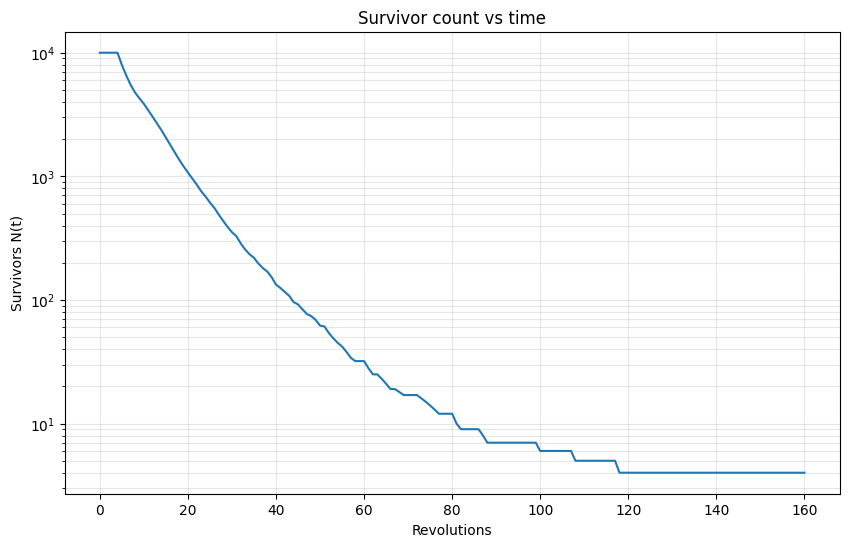

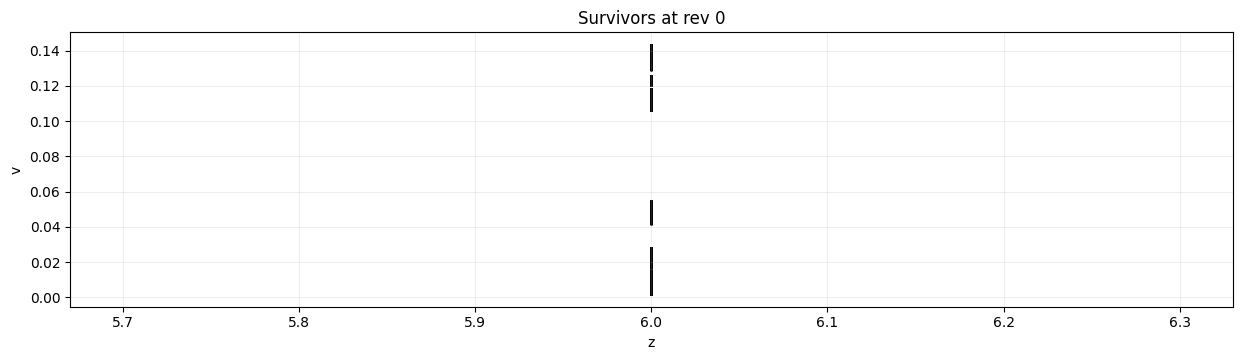

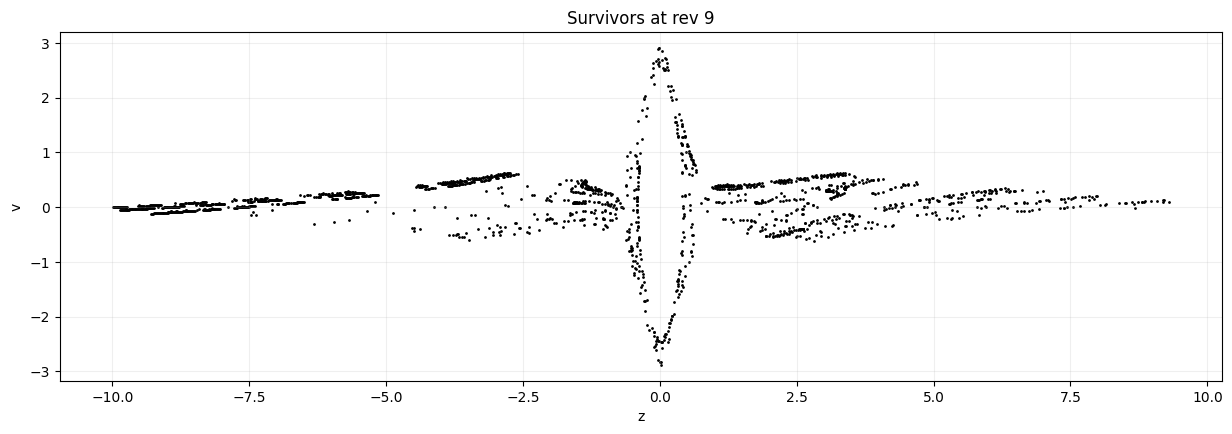

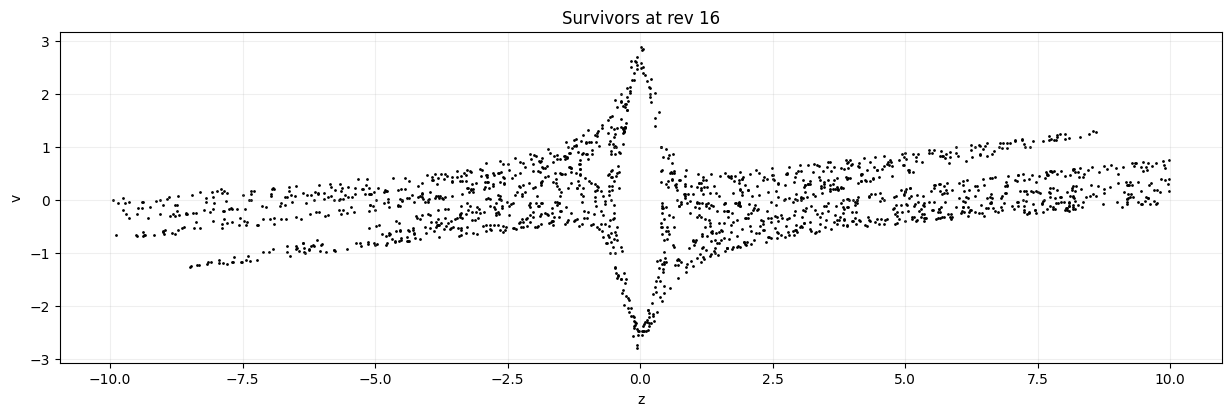

(WindowsPath('C:/Users/Admin/Desktop/TFG/CelestialMechanics/sitnikov/experiments/chaotic_saddle_replicate/data/runs/benchmark_10k/plots/survivor_curve.png'),
 WindowsPath('C:/Users/Admin/Desktop/TFG/CelestialMechanics/sitnikov/experiments/chaotic_saddle_replicate/data/runs/benchmark_10k/plots/survivors_rev_0.png'),
 WindowsPath('C:/Users/Admin/Desktop/TFG/CelestialMechanics/sitnikov/experiments/chaotic_saddle_replicate/data/runs/benchmark_10k/plots/survivors_rev_9.png'),
 WindowsPath('C:/Users/Admin/Desktop/TFG/CelestialMechanics/sitnikov/experiments/chaotic_saddle_replicate/data/runs/benchmark_10k/plots/survivors_rev_16.png'))

In [24]:
survivor_curve_path = plot_survivor_curve(
    results['escape_count'],
    config.n0,
    Path(run_dir) / 'plots' / 'survivor_curve.png',
)

initial_path = plot_survivor_scatter(
    results['initial_points'],
    'Survivors at rev 0',
    Path(run_dir) / 'plots' / 'survivors_rev_0.png',
)

intermediate_path = plot_survivor_scatter(
    results['intermediate_points'],
    'Survivors at rev 9',
    Path(run_dir) / 'plots' / 'survivors_rev_9.png',
)

final_path = plot_survivor_scatter(
    results['final_points'],
    'Survivors at rev 16',
    Path(run_dir) / 'plots' / 'survivors_rev_16.png',
)

survivor_curve_path, initial_path, intermediate_path, final_path

### Benchmark checks

In [25]:
survivors_160 = survivors_curve_from_escape_count(results['escape_count'], config.n0)[-1]
print('escape_count sum:', int(results['escape_count'].sum()))
print('survivors at rev 160:', int(survivors_160))
print('accounting check:', int(results['escape_count'].sum() + survivors_160), '==', config.n0)
print('survivors at rev 16:', results['final_points'].shape[0])

escape_count sum: 9996
survivors at rev 160: 4
accounting check: 10000 == 10000
survivors at rev 16: 1791


### Final run

In [ ]:
# Define experiment configuration

final_run_config = ExperimentConfig(
    e=0.57,
    n0=3_000_000,
    z0=6.0,
    vmin=0.0,
    vmax=0.15,
    max_rev=160,
    escape_abs_z=10.0,
    rev_mid=9,
    rev_final=16,
    checkpoint_every_chunks=1,
    chunk_size=50_000,
    rtol=1e-7,
    atol=1e-10,
    solver_method='RK45',
    focal_interp='linear',
)

final_run_kwargs = dict(
    run_label='final_3e6_parallel',
    resume=False,
    calibrate_chunk_size=False,
    parallel_workers=6,
)

final_run_config, final_run_kwargs

(ExperimentConfig(e=0.57, n0=3000000, z0=6.0, vmin=0.0, vmax=0.15, max_rev=160, escape_abs_z=10.0, rev_mid=9, rev_final=16, checkpoint_every_chunks=1, chunk_size=50000, calibrate_chunk_target_seconds=900.0, calibrate_max_samples=2000, rtol=1e-07, atol=1e-10, solver_method='RK45', focal_interp='linear'),
 {'run_label': 'final_3e6_parallel',
  'resume': False,
  'calibrate_chunk_size': False,
  'parallel_workers': 6})

In [ ]:
# Run the experiment

# final_run_dir = run_experiment(final_run_config, **final_run_kwargs)
# final_run_dir

WindowsPath('C:/Users/Admin/Desktop/TFG/CelestialMechanics/sitnikov/experiments/chaotic_saddle_replicate/data/runs/final_3e6_parallel')

## Plotting results

Modify cell below to plot results

In [23]:
# For future plotting we just need to load the data from the directory where it is stored
final_run_dir = Path('data/runs/final_3e6_parallel')
print(final_run_dir)

data\runs\final_3e6_parallel


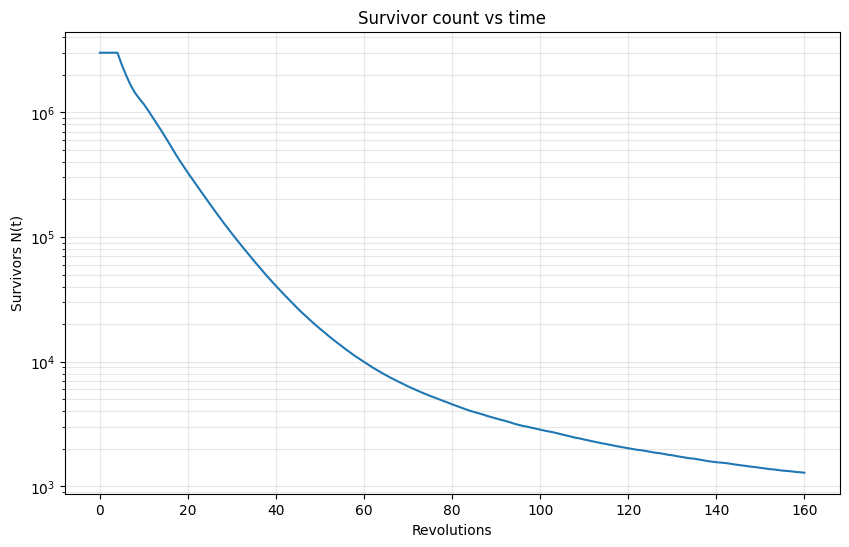

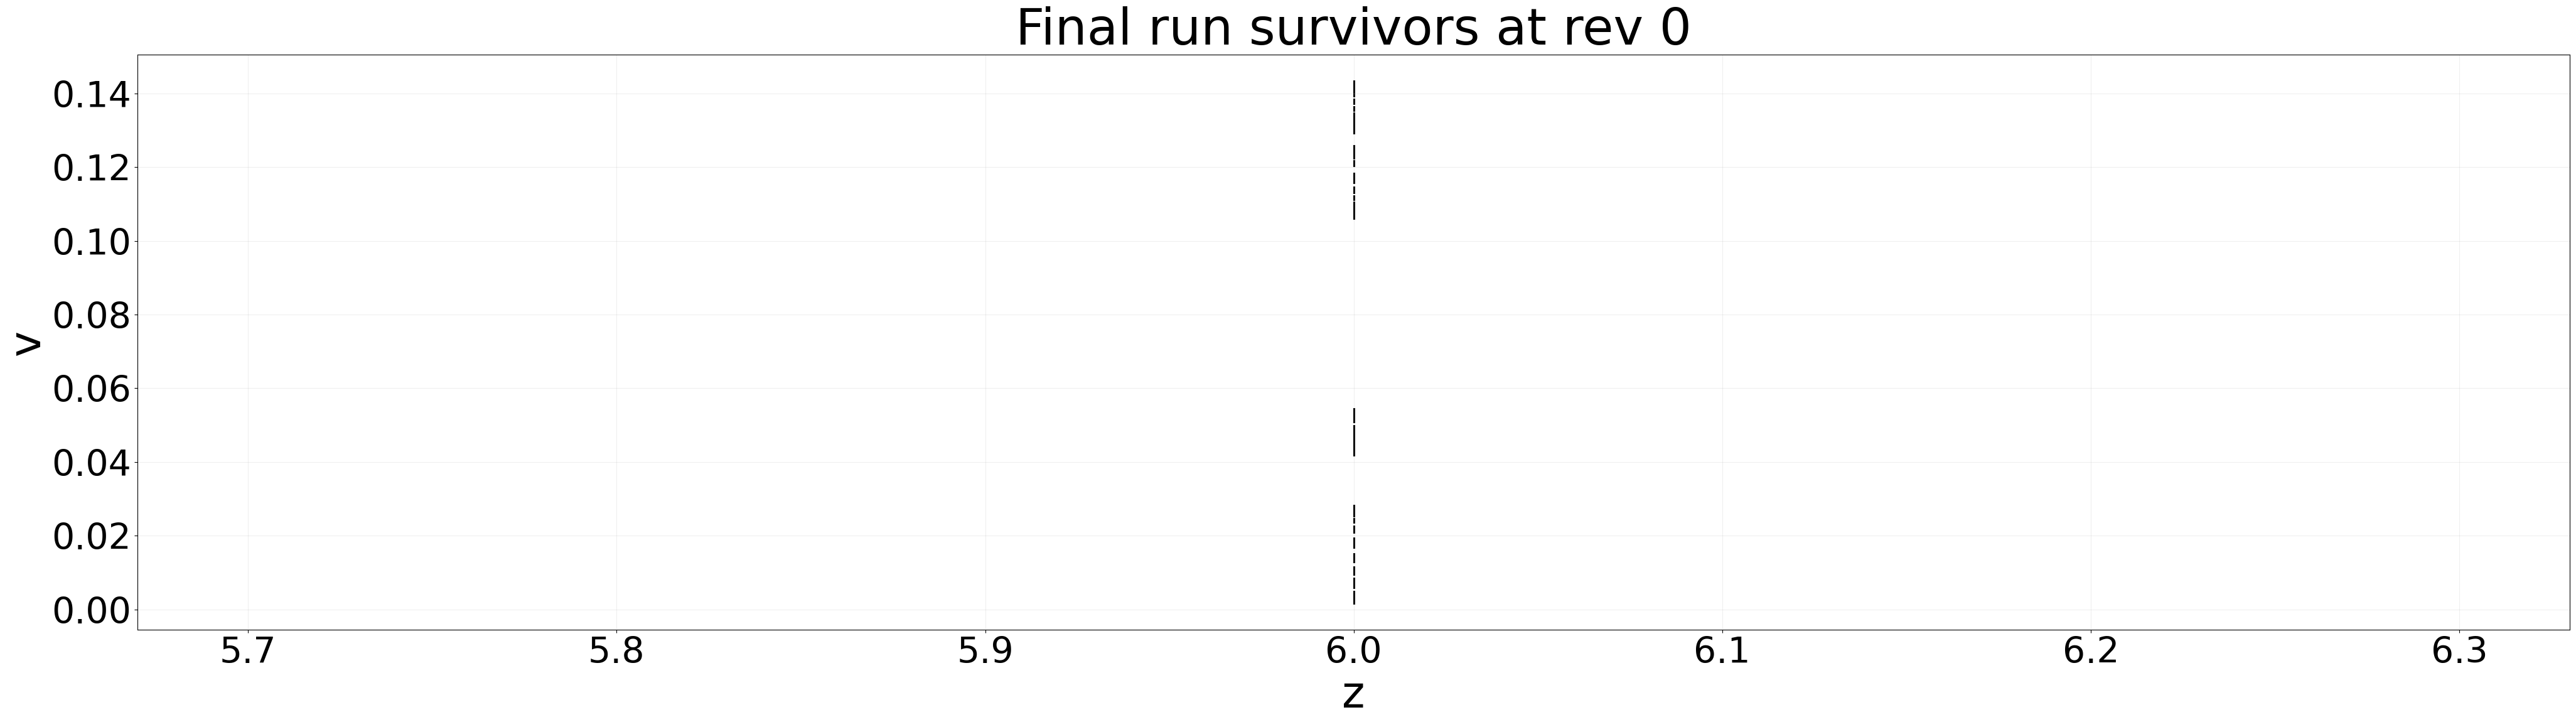

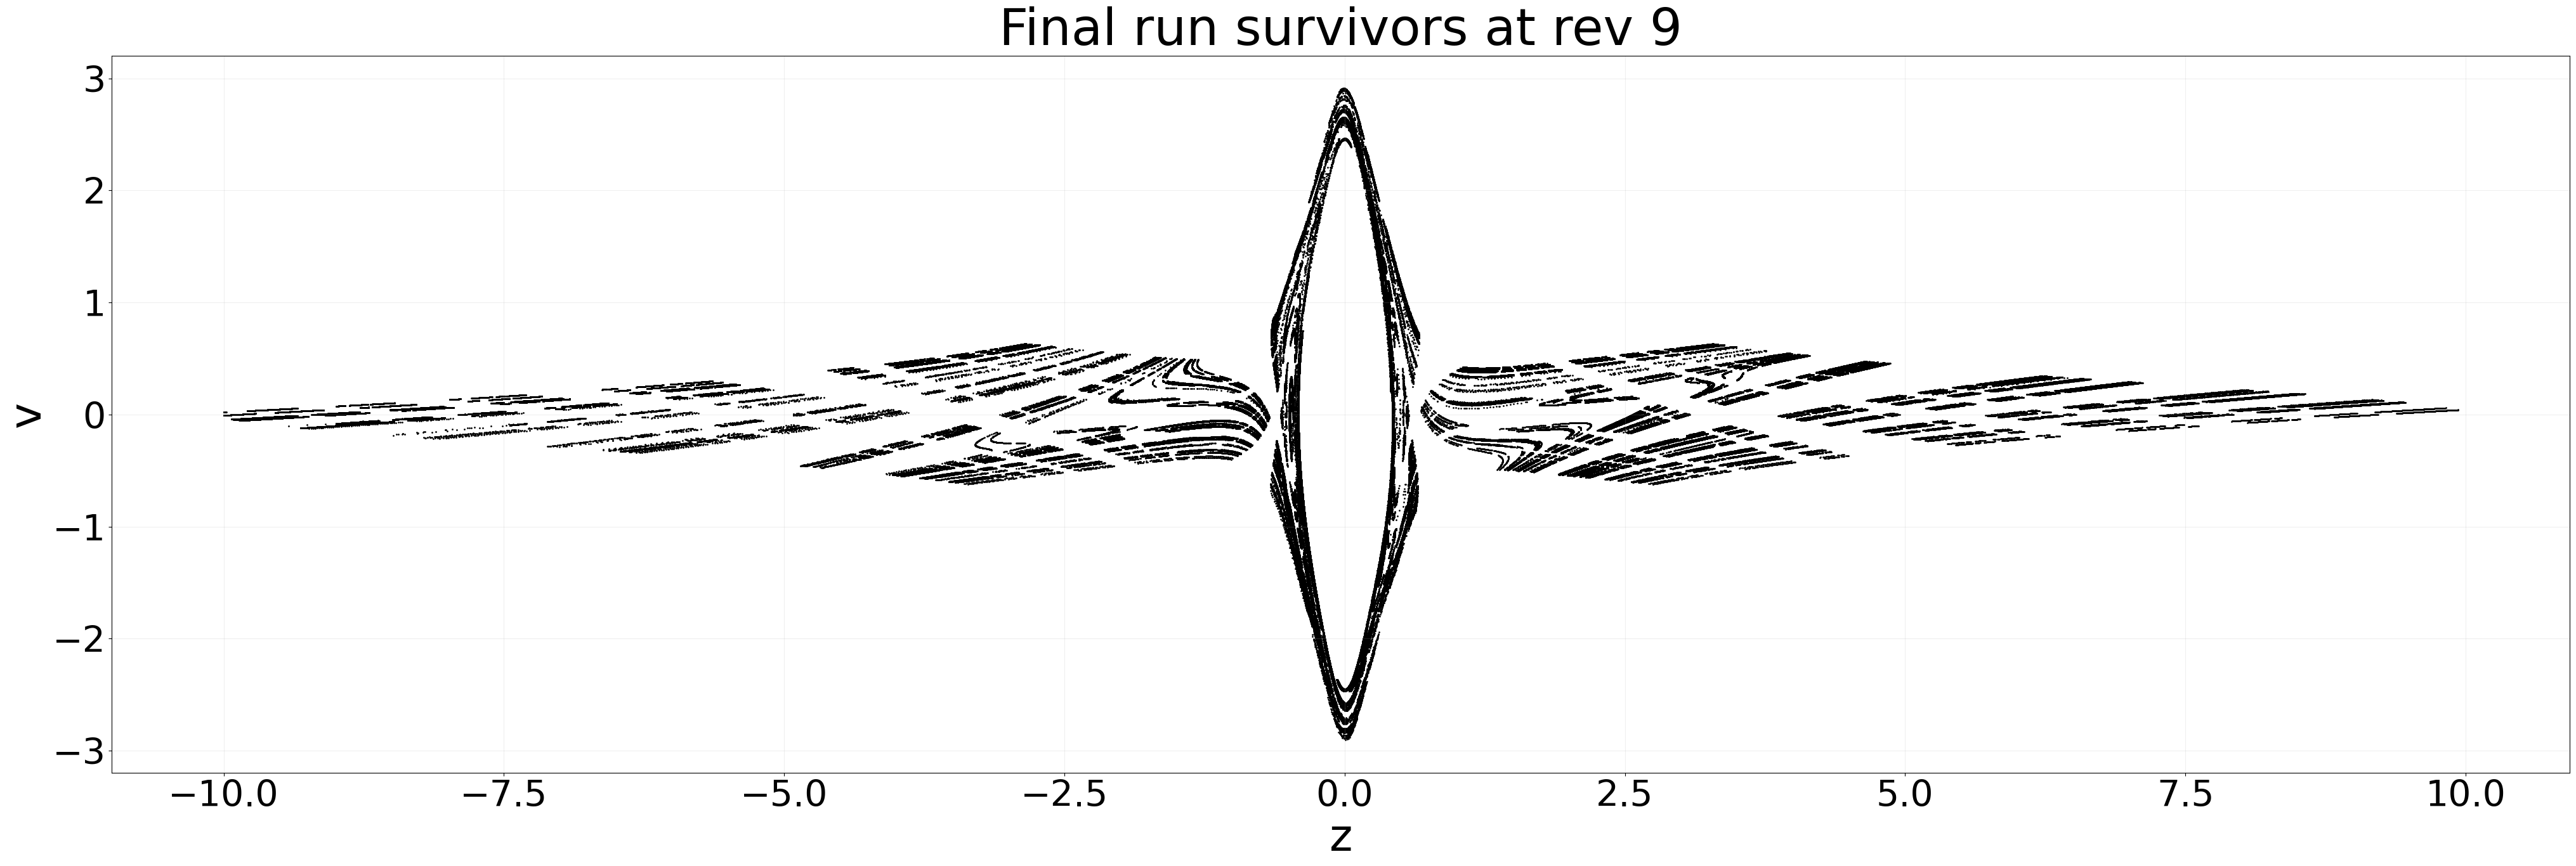

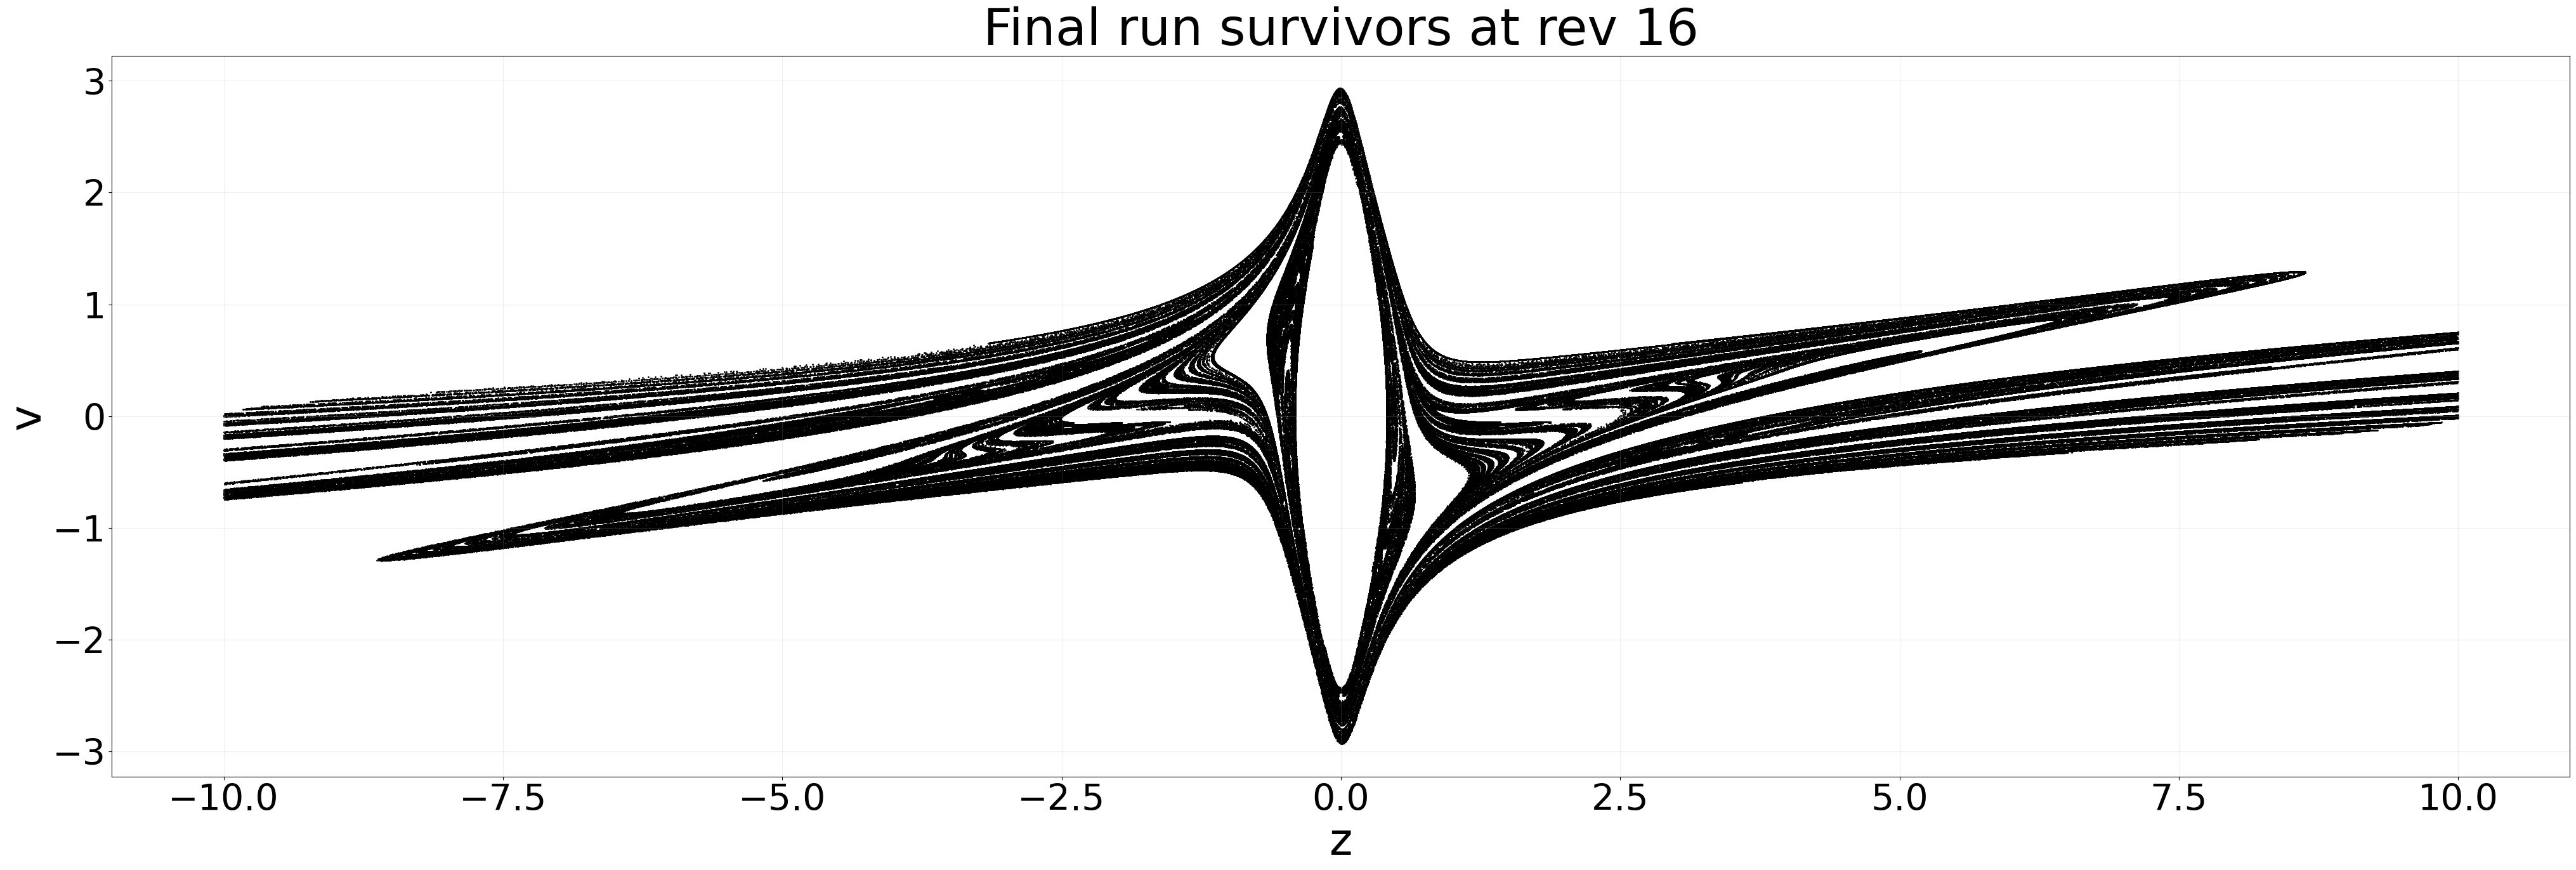

final escape_count sum: 2998712
final survivors at rev 160: 1288
final accounting check: 3000000 == 3000000
final survivors at rev 16: 543560


(None, None, None, None)

In [24]:
final_results = load_results(final_run_dir)

save_figures_flag = False

final_survivor_curve_path = plot_survivor_curve(
    final_results['escape_count'],
    final_run_config.n0,
    Path(final_run_dir) / 'plots' / 'survivor_curve_final.png',
    save_figure_flag=save_figures_flag,
)

final_initial_path = plot_survivor_scatter(
    final_results['initial_points'],
    'Final run survivors at rev 0',
    Path(final_run_dir) / 'plots' / 'survivors_rev_0_final.png',
    fig_side=50,
    save_figure_flag=save_figures_flag,
)

final_intermediate_path = plot_survivor_scatter(
    final_results['intermediate_points'],
    'Final run survivors at rev 9',
    Path(final_run_dir) / 'plots' / 'survivors_rev_9_final.png',
    fig_side=50,
    save_figure_flag=save_figures_flag,
)

final_final_path = plot_survivor_scatter(
    final_results['final_points'],
    'Final run survivors at rev 16',
    Path(final_run_dir) / 'plots' / 'survivors_rev_16_final.png',
    fig_side=50,
    save_figure_flag=save_figures_flag,
)

final_survivors_160 = survivors_curve_from_escape_count(final_results['escape_count'], final_run_config.n0)[-1]
print('final escape_count sum:', int(final_results['escape_count'].sum()))
print('final survivors at rev 160:', int(final_survivors_160))
print('final accounting check:', int(final_results['escape_count'].sum() + final_survivors_160), '==', final_run_config.n0)
print('final survivors at rev 16:', final_results['final_points'].shape[0])

final_survivor_curve_path, final_initial_path, final_intermediate_path, final_final_path

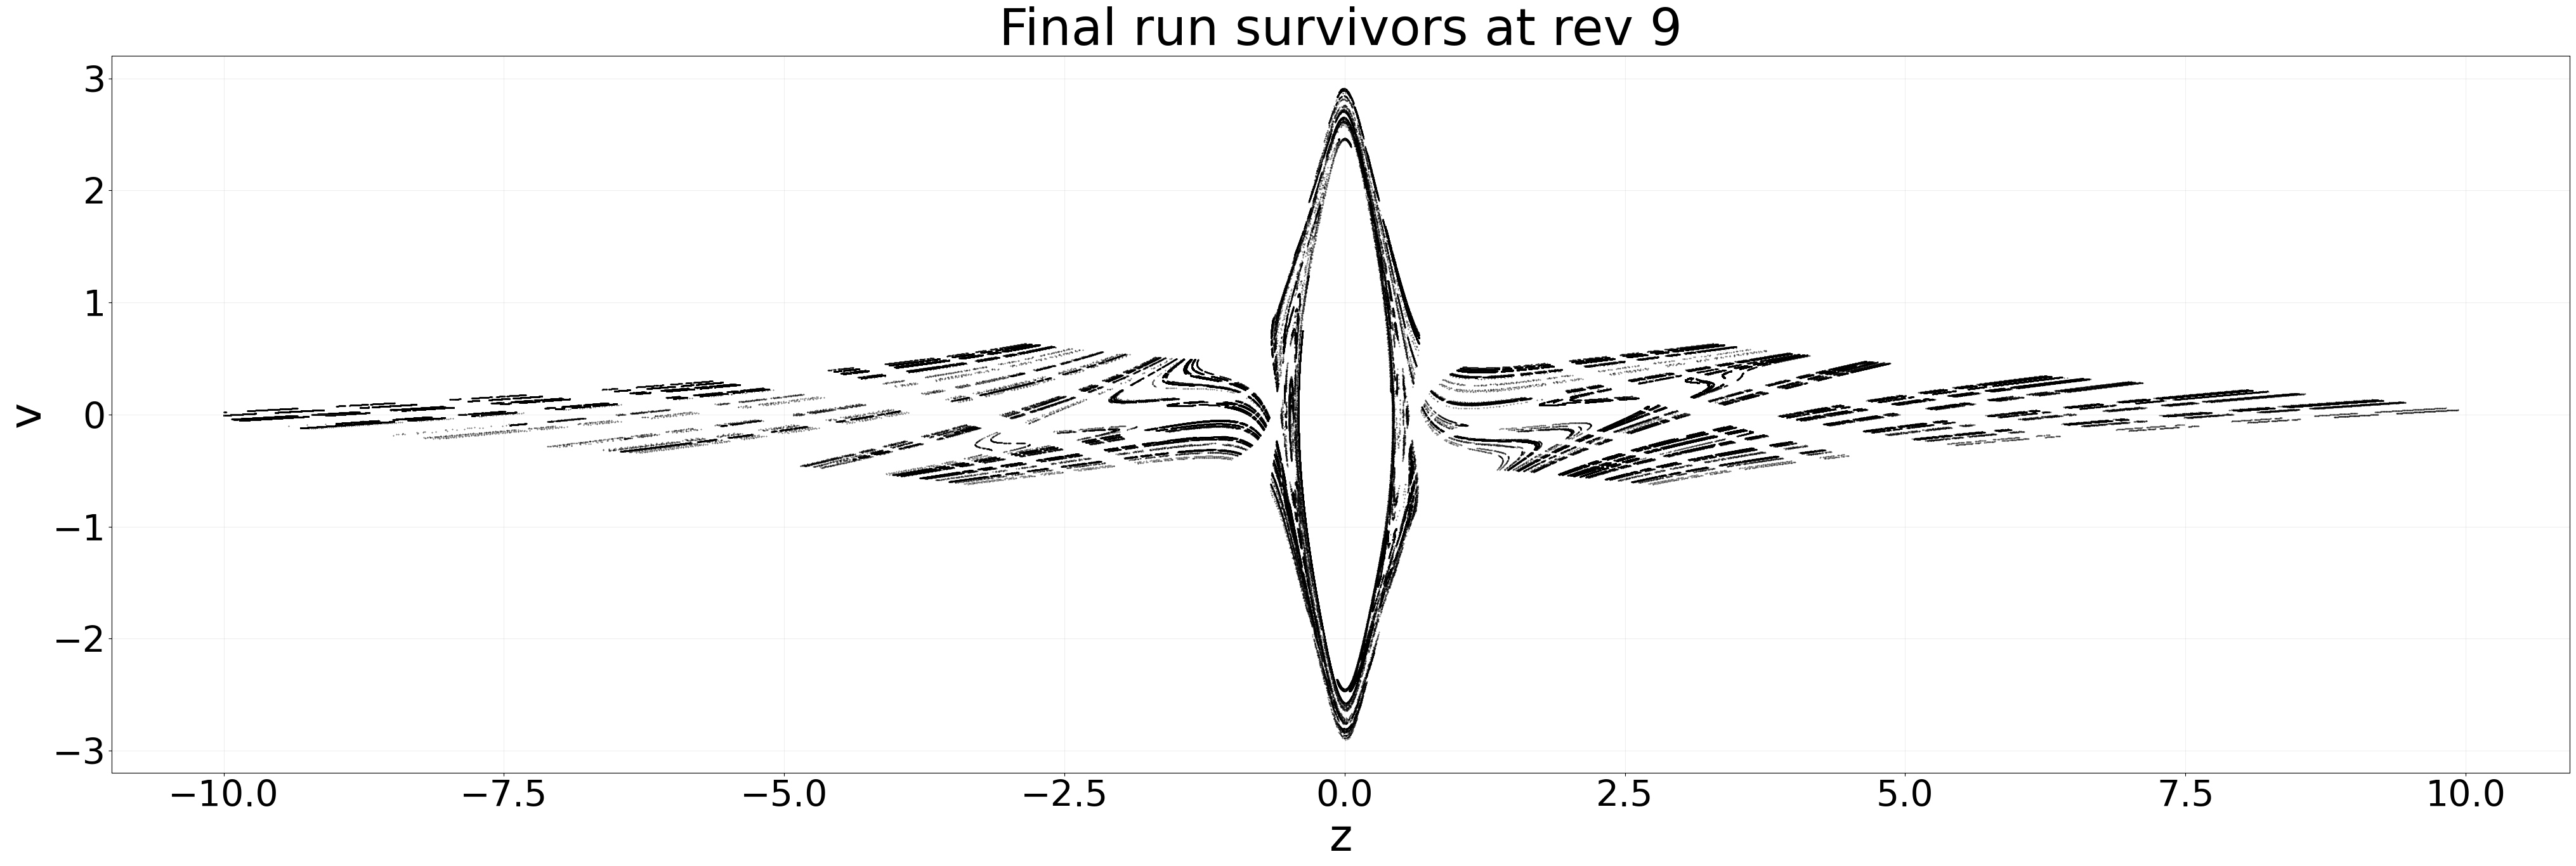

In [20]:
save_figures_flag = False

final_intermediate_path = plot_survivor_scatter(
    final_results['intermediate_points'],
    'Final run survivors at rev 9',
    Path(final_run_dir) / 'plots' / 'survivors_rev_9_final.png',
    fig_side=50,
    dot_size=0.1,
    save_figure_flag=save_figures_flag,
)